# Семестровая работа
## Ревенко Данила, ФИТ-231

In [661]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

№1 Задача регрессии (20 баллов)
Возьмите набор данных согласно своему варианту
(https://cloud.mail.ru/public/AQp5/X3obvSZRo). Датасет представляет собой набор
признаков, признак в последнем столбце является целевым (его надо прогнозировать).
1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения.

In [662]:
df = pd.read_csv('num1.csv', delimiter=';')
df

,1,2,3,4,5,6,7,8,Unnamed: 8
0,-1.285471,-0.082709,0.677226,-1.593587,-0.076688,-0.461126,NaN,-57.929267,NaN
1,0.887142,-0.942467,0.538913,-0.437380,-0.126705,0.211382,0.264608,19.240553,NaN
2,1.438531,0.399838,0.118956,-1.513491,2.022652,-0.175398,NaN,-111.526132,NaN
3,1.245329,1.224764,-1.078584,0.963197,0.789414,-1.022447,-1.648925,-28.604144,NaN
4,-0.740921,0.065722,1.815378,-0.374732,0.058958,-1.098040,NaN,151.220905,NaN
...,...,...,...,...,...,...,...,...,...
95,-0.768383,0.186521,2.527073,-1.611165,-0.271732,1.823238,NaN,120.632158,NaN
96,-0.645783,0.935301,-0.483231,-1.242600,-1.308971,-0.222731,NaN,-147.989655,NaN
97,-0.867497,-0.561476,1.818550,0.304557,-0.468108,-0.261695,0.379584,209.640634,NaN
98,0.868606,-0.257774,-2.618762,0.948042,0.037355,0.450220,NaN,-180.181637,NaN


In [663]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   1           95 non-null     float64
 1   2           100 non-null    float64
 2   3           100 non-null    float64
 3   4           100 non-null    float64
 4   5           100 non-null    float64
 5   6           100 non-null    float64
 6   7           30 non-null     float64
 7   8           100 non-null    float64
 8   Unnamed: 8  0 non-null      float64
dtypes: float64(9)
memory usage: 7.2 KB


Проверим количество NaN значений по столбцам, если их более 15%, то столбец можем удалить

In [664]:
df.isna().sum()

1               5
2               0
3               0
4               0
5               0
6               0
7              70
8               0
Unnamed: 8    100
dtype: int64

Удаляем столбцы с большим количеством пропущенных значений: 7 и Unnamed: 8 и очищаем от пропущенных значений остальные столбцы

In [665]:
df = df.drop(columns=['7', 'Unnamed: 8'])
df = df.dropna()
df.isna().sum()

1    0
2    0
3    0
4    0
5    0
6    0
8    0
dtype: int64

In [666]:
df


,1,2,3,4,5,6,8
0,-1.285471,-0.082709,0.677226,-1.593587,-0.076688,-0.461126,-57.929267
1,0.887142,-0.942467,0.538913,-0.437380,-0.126705,0.211382,19.240553
2,1.438531,0.399838,0.118956,-1.513491,2.022652,-0.175398,-111.526132
3,1.245329,1.224764,-1.078584,0.963197,0.789414,-1.022447,-28.604144
4,-0.740921,0.065722,1.815378,-0.374732,0.058958,-1.098040,151.220905
...,...,...,...,...,...,...,...
95,-0.768383,0.186521,2.527073,-1.611165,-0.271732,1.823238,120.632158
96,-0.645783,0.935301,-0.483231,-1.242600,-1.308971,-0.222731,-147.989655
97,-0.867497,-0.561476,1.818550,0.304557,-0.468108,-0.261695,209.640634
98,0.868606,-0.257774,-2.618762,0.948042,0.037355,0.450220,-180.181637


2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.

In [667]:
df.describe()

,1,2,3,4,5,6,8
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,0.076029,-0.109591,0.304696,0.047764,-0.107540,-0.137915,19.450817
std,1.070353,0.983209,1.468232,1.007875,1.040149,0.945813,128.375640
min,-3.568341,-2.790651,-2.619051,-2.107509,-2.694094,-2.250109,-283.821674
25%,-0.693352,-0.654590,-0.488451,-0.632711,-0.700775,-0.826841,-68.887374
50%,0.196325,-0.082709,0.231128,0.126371,-0.098953,-0.171084,28.409068
75%,0.874419,0.413168,0.952652,0.667134,0.568378,0.423728,105.226428
max,2.567481,2.028566,7.493179,2.515212,2.555169,2.705192,362.998775


<Axes: xlabel='8', ylabel='Count'>

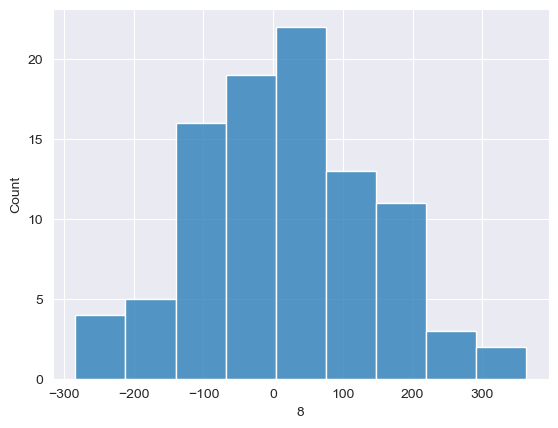

In [668]:
sns.histplot(df['8'])

Гистограмма показывает унимодальное (с одним пиком) распределение целевого признака с пиком примерно в диапазоне 0 до 50, небольшой правой скошенностью и редкими выбросами в хвостах.

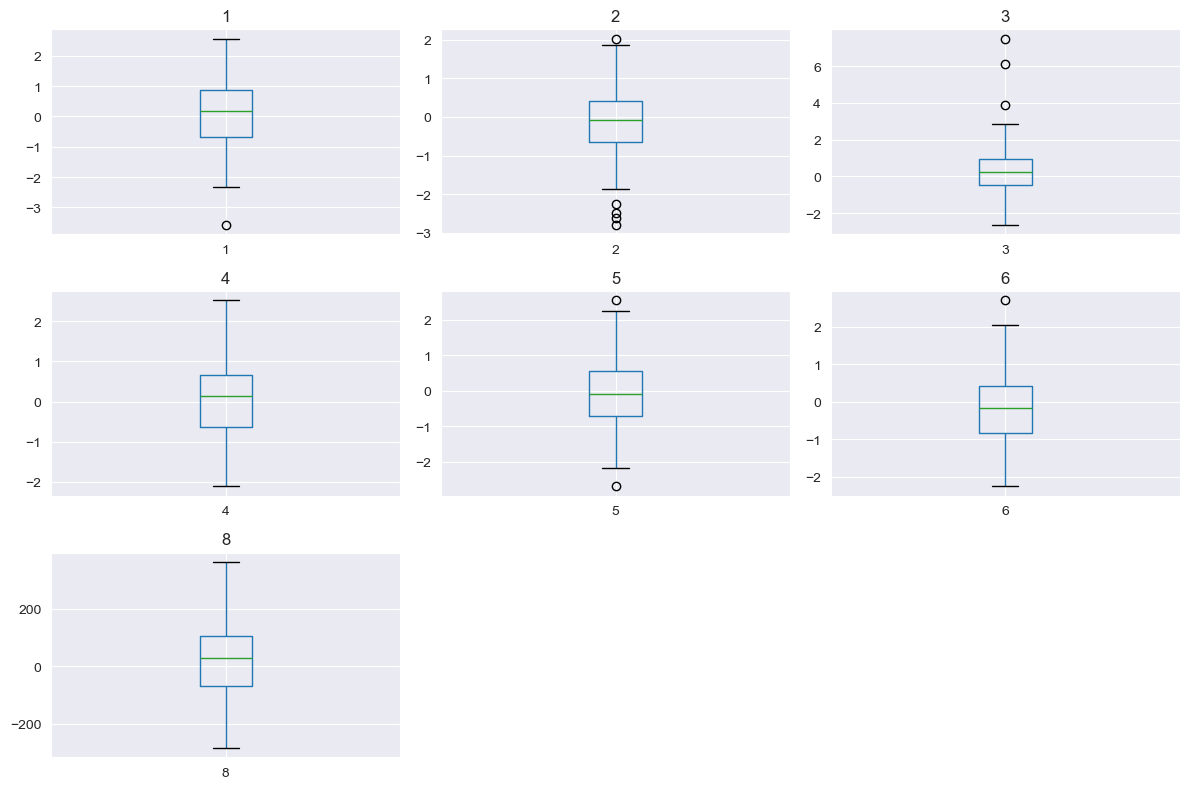

In [669]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

df.boxplot(column='1', ax=axes[0, 0])
axes[0, 0].set_title('1')

df.boxplot(column='2', ax=axes[0, 1])
axes[0, 1].set_title('2')

df.boxplot(column='3', ax=axes[0, 2])
axes[0, 2].set_title('3')

df.boxplot(column='4', ax=axes[1, 0])
axes[1, 0].set_title('4')

df.boxplot(column='5', ax=axes[1, 1])
axes[1, 1].set_title('5')

df.boxplot(column='6', ax=axes[1, 2])
axes[1, 2].set_title('6')

df.boxplot(column='8', ax=axes[2, 0])
axes[2, 0].set_title('8')

fig.delaxes(axes[2, 1])
fig.delaxes(axes[2, 2])

plt.tight_layout()
plt.show()


Боксплоты не показывают точную форму распределения, но помогают оценить его центр и разброс, а также быстро выявить возможные выбросы.

Выполняем винзоризацию (ограничение выбросов) для уменьшения влияния выбросов на корреляционный анализ.

Для каждого признака считаем:

Q1 — 25-й перцентиль (нижний квартиль)

Q3 — 75-й перцентиль (верхний квартиль)

IQR = Q3 − Q1 — межквартильный размах (разброс “середины” данных)


По IQR задаём границы “нормальных” значений:

нижняя граница: Q1 − 1.5 * IQR

верхняя граница: Q3 + 1.5 * IQR

Любые значения:

меньше нижней границы → заменяются на нижнюю границу

больше верхней границы → заменяются на верхнюю границу

остальные остаются как есть

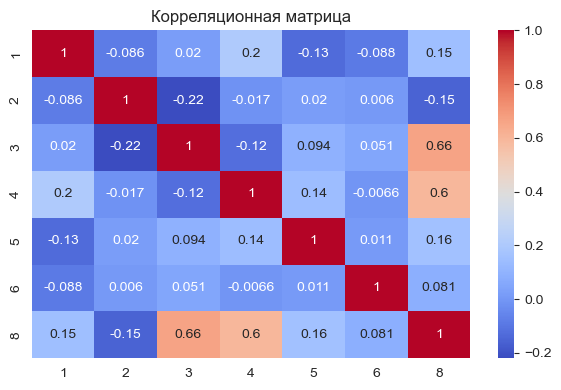

In [670]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_clipped = df.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, axis=1)

plt.figure(figsize=(6, 4))
correlation_matrix = df_clipped.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()


Признак 6 имеет крайне слабую корреляцию с целевым признаком (|r| < 0.1), поэтому исключаем из модели как неинформативный.

In [671]:
df_clipped = df_clipped.drop(columns='6')
df_clipped

,1,2,3,4,5,8
0,-1.285471,-0.082709,0.677226,-1.593587,-0.076688,-57.929267
1,0.887142,-0.942467,0.538913,-0.437380,-0.126705,19.240553
2,1.438531,0.399838,0.118956,-1.513491,2.022652,-111.526132
3,1.245329,1.224764,-1.078584,0.963197,0.789414,-28.604144
4,-0.740921,0.065722,1.815378,-0.374732,0.058958,151.220905
...,...,...,...,...,...,...
95,-0.768383,0.186521,2.527073,-1.611165,-0.271732,120.632158
96,-0.645783,0.935301,-0.483231,-1.242600,-1.308971,-147.989655
97,-0.867497,-0.561476,1.818550,0.304557,-0.468108,209.640634
98,0.868606,-0.257774,-2.618762,0.948042,0.037355,-180.181637


3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).

Нормализуем датасет (предобработка, при которой значения признаков приводятся к единому масштабу)

In [672]:
X = df_clipped.drop(columns='8')
y = df_clipped['8']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


4. Для предсказания целевого признака постройте следующие модели, используя
библиотеку sklearn:
5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.

a. Линейная регрессия LinearRegression()

In [673]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"MSE (обучающая выборка): {mse_train:.4f}")
print(f"R^2 (обучающая выборка): {r2_train:.4f}")
print(f"MSE (тестовая выборка): {mse_test:.4f}")
print(f"R^2 (тестовая выборка): {r2_test:.4f}")

MSE (обучающая выборка): 1582.3635
R^2 (обучающая выборка): 0.8977
MSE (тестовая выборка): 1629.1293
R^2 (тестовая выборка): 0.9035


b. Случайный лес RandomForestRegressor()

In [674]:
rfr = RandomForestRegressor()
rfr.fit(X_train, y_train)

y_pred_train = rfr.predict(X_train)
y_pred_test = rfr.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"MSE (обучающая выборка): {mse_train:.4f}")
print(f"R^2 (обучающая выборка): {r2_train:.4f}")
print(f"MSE (тестовая выборка): {mse_test:.4f}")
print(f"R^2 (тестовая выборка): {r2_test:.4f}")

MSE (обучающая выборка): 463.3787
R^2 (обучающая выборка): 0.9700
MSE (тестовая выборка): 3619.7069
R^2 (тестовая выборка): 0.7857


c. Метод ближайших соседей KNeighborsRegressor()

In [675]:

# Определяем диапазон k для проверки
param_grid = {'n_neighbors': np.arange(1, 20)}

knn = KNeighborsRegressor()
# Ищем лучшее значение k с помощью GridSearchCV
grid_search = GridSearchCV(knn, param_grid, cv=5)

grid_search.fit(X_train, y_train)

# Выводим лучшее значение k и соответствующую точность
print(f"Оптимальное значение k: {grid_search.best_params_['n_neighbors']}")
print(f"Лучшая точность при кросс-валидации: {grid_search.best_score_:.4f}")


Оптимальное значение k: 3
Лучшая точность при кросс-валидации: 0.6684


In [676]:

neigh = KNeighborsRegressor(n_neighbors=3)
neigh.fit(X_train, y_train)

y_pred_train = neigh.predict(X_train)
y_pred_test = neigh.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"MSE (обучающая выборка): {mse_train:.4f}")
print(f"R^2 (обучающая выборка): {r2_train:.4f}")
print(f"MSE (тестовая выборка): {mse_test:.4f}")
print(f"R^2 (тестовая выборка): {r2_test:.4f}")


MSE (обучающая выборка): 2749.2322
R^2 (обучающая выборка): 0.8222
MSE (тестовая выборка): 4555.9464
R^2 (тестовая выборка): 0.7302


d. Метод опорных векторов SVR()


In [677]:
# Задаём сетку параметров для перебора
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1]
}

# Создаём модель SVR с линейным ядром
svr = SVR(kernel='linear')

# Ищем лучшие гиперпараметры с помощью GridSearchCV
grid = GridSearchCV(
    svr,
    param_grid,
    cv=5,
    scoring='r2'
)

# Обучаем GridSearchCV на тренировочных данных
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучший R^2 (CV):", grid.best_score_)


Лучшие параметры: {'C': 10, 'epsilon': 1}
Лучший R^2 (CV): 0.7654595636915154


In [678]:
svr = SVR(kernel='linear', C=10, epsilon=1)
svr.fit(X_train, y_train)

y_pred_train = svr.predict(X_train)
y_pred_test = svr.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"MSE (обучающая выборка): {mse_train:.4f}")
print(f"R^2 (обучающая выборка): {r2_train:.4f}")
print(f"MSE (тестовая выборка): {mse_test:.4f}")
print(f"R^2 (тестовая выборка): {r2_test:.4f}")

MSE (обучающая выборка): 2344.4610
R^2 (обучающая выборка): 0.8484
MSE (тестовая выборка): 1359.6793
R^2 (тестовая выборка): 0.9195


6. Оцените качество работы моделей. Выведите для каждой модели ее score().
Напишите какая модель дала наилучший результат. Выведите ее значение
feature_importances_


На тренировочных данных лучший результат дала модель RandomForestRegressor()(случайного леса)

На тестовых данных - метод опорных векторов SVR()

In [679]:
print(rfr.feature_importances_)

[0.0156178  0.01770417 0.45550936 0.48591074 0.02525794]


для SVR: “важность признаков оценим по коэффициентам coef_

In [680]:
print(svr.coef_)

[[ -0.62656645  -0.92366747 104.62386066  77.69745453  -0.34078765]]


№2 Задача классификации (20 баллов)
Возьмите набор данных согласно своему варианту
(https://cloud.mail.ru/public/MWZh/DQkbAHKmi). Датасет представляет собой набор
признаков, в последнем столбце указан класс объекта.
1. Проведите предварительный анализ и подготовку данных, обработайте
пропущенные значения.

In [681]:
df = pd.read_csv('num2.csv', delimiter=';')
df

,1,2,3,4,5,6,7,8
0,0.857794,1.191141,-2.501944,-0.072310,0.927593,-2.501944,2.062941,1
1,0.974847,0.245309,0.588575,-1.816516,0.754855,0.588575,2.070349,2
2,0.965456,-0.211132,0.891785,-1.046728,-0.564424,0.891785,-0.018404,2
3,0.063394,0.188988,1.323047,-0.488879,0.588116,1.323047,1.652926,2
4,0.023869,-1.689940,-0.985888,-0.581443,1.084856,-0.985888,1.410528,1
...,...,...,...,...,...,...,...,...
95,0.330809,0.496897,1.191611,-2.132284,0.168255,1.191611,-0.183433,1
96,1.180839,-0.943616,1.055178,-1.697694,-0.920702,1.055178,-0.866714,0
97,1.990013,-0.053940,-0.797827,-1.646157,-0.532564,-0.797827,0.384690,1
98,1.761664,-0.880580,-3.098523,0.601187,0.506036,-3.098523,2.858153,1


In [682]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       95 non-null     float64
 1   2       100 non-null    float64
 2   3       100 non-null    float64
 3   4       95 non-null     float64
 4   5       100 non-null    float64
 5   6       100 non-null    float64
 6   7       100 non-null    float64
 7   8       100 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 6.4 KB


Также проверяем количество NaN значений по столбцам, если их более 15%, то столбец можем удалить

In [683]:
df.isna().sum()

1    5
2    0
3    0
4    5
5    0
6    0
7    0
8    0
dtype: int64

Столбцов с большим количеством пропущенных значений нет, поэтому столбцы целиком не удаляем. Только очищаем от пропущенных значений

In [684]:
df = df.dropna()
df.isna().sum()

1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

In [685]:
df

,1,2,3,4,5,6,7,8
0,0.857794,1.191141,-2.501944,-0.072310,0.927593,-2.501944,2.062941,1
1,0.974847,0.245309,0.588575,-1.816516,0.754855,0.588575,2.070349,2
2,0.965456,-0.211132,0.891785,-1.046728,-0.564424,0.891785,-0.018404,2
3,0.063394,0.188988,1.323047,-0.488879,0.588116,1.323047,1.652926,2
4,0.023869,-1.689940,-0.985888,-0.581443,1.084856,-0.985888,1.410528,1
...,...,...,...,...,...,...,...,...
94,1.580120,-0.396851,0.871551,-1.245822,-0.487639,0.871551,0.979329,2
95,0.330809,0.496897,1.191611,-2.132284,0.168255,1.191611,-0.183433,1
96,1.180839,-0.943616,1.055178,-1.697694,-0.920702,1.055178,-0.866714,0
97,1.990013,-0.053940,-0.797827,-1.646157,-0.532564,-0.797827,0.384690,1


2. Проведите статистический анализ, оцените корреляции между признаками, оцените
возможные выбросы в данных, постройте поясняющие графики. Удалите из
рассмотрения признаки, которые не влияют на целевой.

In [686]:
df.describe()

,1,2,3,4,5,6,7,8
count,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,1.395025,0.092089,0.274398,-0.904753,-0.217213,0.274398,0.545203,1.044444
std,3.391563,0.950400,1.542133,0.892225,0.860763,1.542133,1.337910,0.806032
min,-6.126172,-1.822825,-4.098430,-2.955793,-2.241120,-4.098430,-2.808024,0.000000
25%,0.335916,-0.640638,-0.571980,-1.510644,-0.866994,-0.571980,-0.228935,0.000000
50%,1.102547,0.085388,0.752727,-1.118258,-0.233855,0.752727,0.464788,1.000000
75%,1.594318,0.704034,1.181329,-0.254628,0.408715,1.181329,1.694591,2.000000
max,29.221409,2.130651,3.516411,1.362547,1.907537,3.516411,3.225826,2.000000


<Axes: xlabel='8', ylabel='Count'>

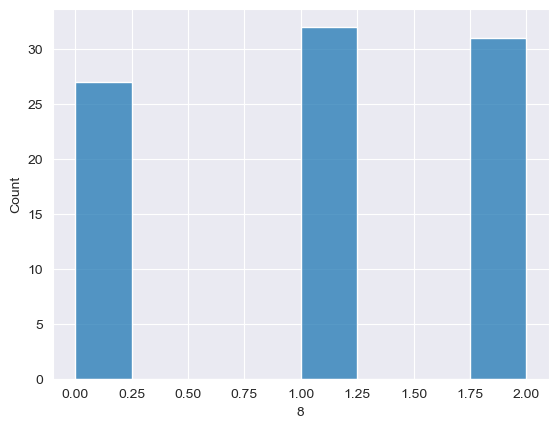

In [687]:
sns.histplot(df['8'])

Гистограмма показывает распределение целевого признака 8 по трём значениям (0, 1, 2): чаще всего встречается 1, затем 2, реже всего 0; сильного дисбаланса нет, но есть небольшой перекос в сторону 1.

Оценим выбросы с помощью боксплотов

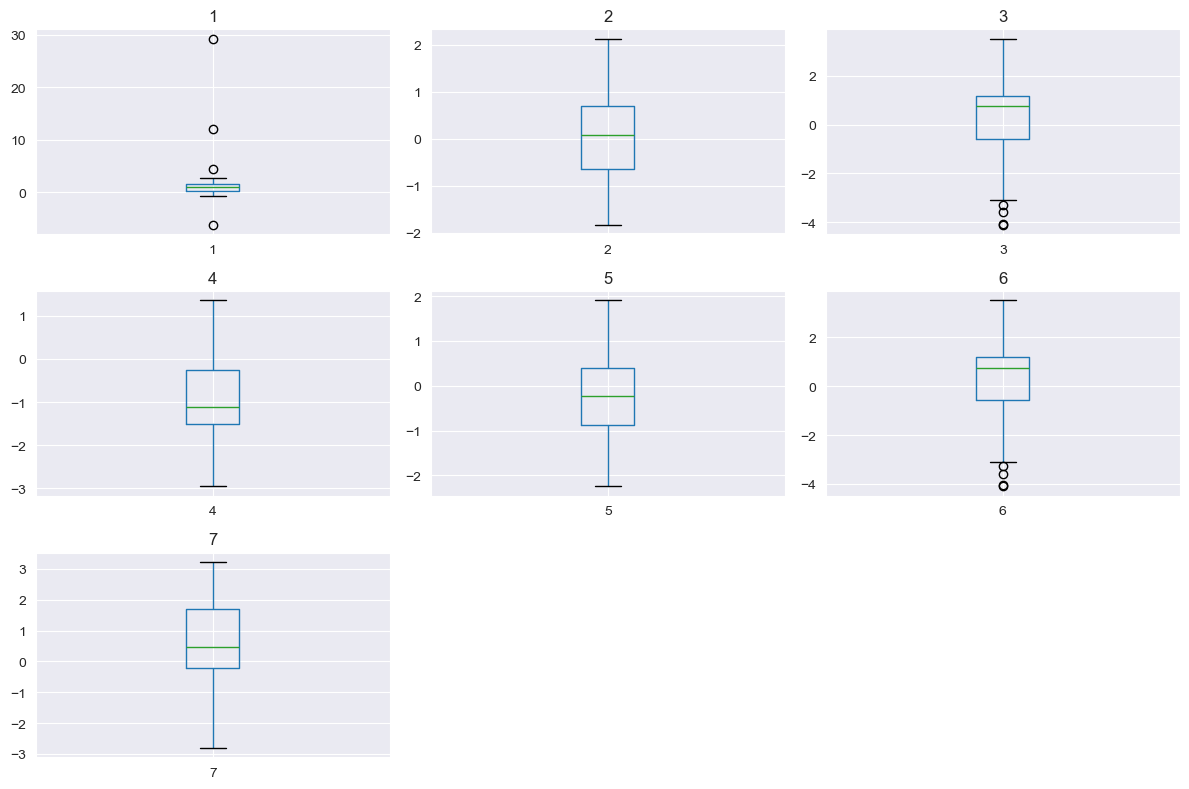

In [688]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

df.boxplot(column='1', ax=axes[0, 0])
axes[0, 0].set_title('1')

df.boxplot(column='2', ax=axes[0, 1])
axes[0, 1].set_title('2')

df.boxplot(column='3', ax=axes[0, 2])
axes[0, 2].set_title('3')

df.boxplot(column='4', ax=axes[1, 0])
axes[1, 0].set_title('4')

df.boxplot(column='5', ax=axes[1, 1])
axes[1, 1].set_title('5')

df.boxplot(column='6', ax=axes[1, 2])
axes[1, 2].set_title('6')

df.boxplot(column='7', ax=axes[2, 0])
axes[2, 0].set_title('7')


fig.delaxes(axes[2, 1])
fig.delaxes(axes[2, 2])

plt.tight_layout()
plt.show()

Выполняем винзоризацию (ограничение выбросов) для уменьшения влияния выбросов на корреляционный анализ.

Для каждого признака считаем:

Q1 — 25-й перцентиль (нижний квартиль)

Q3 — 75-й перцентиль (верхний квартиль)

IQR = Q3 − Q1 — межквартильный размах (разброс “середины” данных)


По IQR задаём границы “нормальных” значений:

нижняя граница: Q1 − 1.5 * IQR

верхняя граница: Q3 + 1.5 * IQR

Любые значения:

меньше нижней границы → заменяются на нижнюю границу

больше верхней границы → заменяются на верхнюю границу

остальные остаются как есть

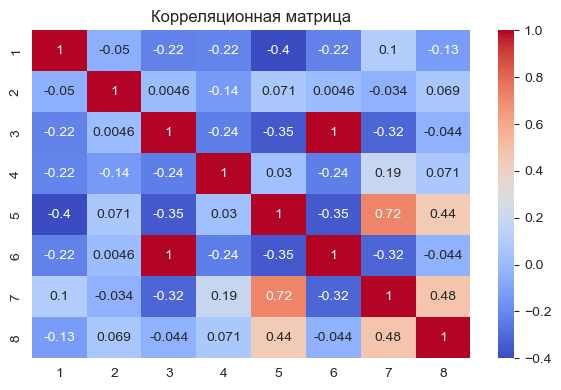

In [689]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df_clipped = df.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, axis=1)

plt.figure(figsize=(6, 4))
correlation_matrix = df_clipped.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()


3 и 6 признаки имеют корреляцию = 1, что означает, поэтому можем удалить один из них (например, 3).

In [690]:
df_clipped = df_clipped.drop(columns=['3'])
df_clipped

,1,2,4,5,6,7,8
0,0.857794,1.191141,-0.072310,0.927593,-2.501944,2.062941,1
1,0.974847,0.245309,-1.816516,0.754855,0.588575,2.070349,2
2,0.965456,-0.211132,-1.046728,-0.564424,0.891785,-0.018404,2
3,0.063394,0.188988,-0.488879,0.588116,1.323047,1.652926,2
4,0.023869,-1.689940,-0.581443,1.084856,-0.985888,1.410528,1
...,...,...,...,...,...,...,...
94,1.580120,-0.396851,-1.245822,-0.487639,0.871551,0.979329,2
95,0.330809,0.496897,-2.132284,0.168255,1.191611,-0.183433,1
96,1.180839,-0.943616,-1.697694,-0.920702,1.055178,-0.866714,0
97,1.990013,-0.053940,-1.646157,-0.532564,-0.797827,0.384690,1


3. Разбейте выборку на тренировочные и тестовые данные (60% на 40%).

In [691]:
X = df_clipped.drop(columns='8')
y = df_clipped['8']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

4. Для предсказания класса постройте две модели, используя библиотеку sklearn:

a. Случайный лес RandomForestClassifier()

In [692]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Random Forest Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.46      0.86      0.60         7
           1       0.94      0.88      0.91        17
           2       0.86      0.50      0.63        12

    accuracy                           0.75        36
   macro avg       0.75      0.75      0.71        36
weighted avg       0.82      0.75      0.76        36

[[ 6  0  1]
 [ 2 15  0]
 [ 5  1  6]]


Подберем гиперпараметры для модели RandomForestClassifier с помощью GridSearchCV:

_estimators (сколько деревьев), max_depth (глубина деревьев), max_features (сколько признаков пробовать в узле), min_samples_split (минимум объектов для разбиения), min_samples_leaf (минимум объектов в листе), bootstrap (обучать деревья на случайных подвыборках или на всех данных)

In [693]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
        estimator=clf,
        param_grid=param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)

best_clf = grid_search.best_estimator_

y_pred = best_clf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

{'bootstrap': False, 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Random Forest Accuracy: 0.7777777777777778
              precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.94      0.88      0.91        17
           2       0.88      0.58      0.70        12

    accuracy                           0.78        36
   macro avg       0.77      0.77      0.75        36
weighted avg       0.83      0.78      0.79        36

[[ 6  0  1]
 [ 2 15  0]
 [ 4  1  7]]


b. Метод ближайших соседей KNeighborsClassifier()

In [694]:
neigh = KNeighborsClassifier()
neigh.fit(X_train, y_train)

y_pred = neigh.predict(X_test)

print("KNeighbors Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

KNeighbors Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.92      0.71      0.80        17
           2       0.73      0.67      0.70        12

    accuracy                           0.72        36
   macro avg       0.72      0.74      0.71        36
weighted avg       0.78      0.72      0.73        36

[[ 6  0  1]
 [ 3 12  2]
 [ 3  1  8]]


Подберем оптимальные гиперпараметры для KNeighborsClassifier с помощью GridSearchCV:

n_neighbors (сколько соседей учитывать), weights (все соседи равны или ближние важнее), metric/p (как считать расстояние между объектами)

In [695]:
param_grid_knn = {
    'n_neighbors': range(1, 20),
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()


grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))


KNN Accuracy: 0.7222222222222222
              precision    recall  f1-score   support

           0       0.56      0.71      0.62         7
           1       0.92      0.71      0.80        17
           2       0.64      0.75      0.69        12

    accuracy                           0.72        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.76      0.72      0.73        36

[[ 5  0  2]
 [ 2 12  3]
 [ 2  1  9]]


5. Для каждой модели попытайтесь добиться наилучшего возможного результата
предсказания.

6. Оцените качество работы моделей. Выведите метрики модели. Напишите какая
модель дала наилучший результат.

### RandomForestClassifier

До подбора гиперпараметров: Accuracy = 0.75

После GridSearchCV (лучшие параметры: bootstrap=False, max_features='log2', min_samples_split=10, n_estimators=100): Accuracy = 0.78

По classification_report после подбора видно, что лучше всего распознаётся класс 1 (precision=0.94, recall=0.88), хуже всего - класс 0 (precision=0.50).

### KNeighborsClassifier

До подбора: Accuracy = 0.72

После подбора оптимального числа соседей: Accuracy = 0.72 (улучшения не произошло)

Модель показывает более “ровные” значения recall по классам, но в целом уступает RandomForest по общей точности.

### Итог

Лучшая модель по качеству на тестовых данных - RandomForestClassifier после GridSearchCV, так как она показала максимальную точность:

Accuracy = 0.78 (лучше, чем 0.75 без подбора и 0.72 у KNN).